# Counterfactual Explanation in Allegro Pay

**Warsaw University of Technology — Final Project**

---

This notebook provides boilerplate code to help you get started. It covers:

1. Environment verification & imports
2. Data loading & initial EDA
3. Feature engineering (skeleton)
4. Feature selection (Boruta)
5. Model training (LightGBM)
6. Model serialization
7. Counterfactual generation (DiCE & Alibi)
8. Evaluation & Benchmarking (DALEX)

> **Instructions:** Fork this repo, fill in the `TODO` sections, and extend the analysis.
> Delete or modify this boilerplate as your project evolves.

## 1. Imports & Configuration

In [1]:
# Standard library
import pickle
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import lightgbm as lgb
# import xgboost as xgb    # Uncomment if using XGBoost
# import catboost as cb     # Uncomment if using CatBoost

# Counterfactual Explanation packages
import dice_ml
import alibi               # Uncomment when implementing Alibi

# Project config
import sys
sys.path.insert(0, str(Path.cwd().parent))  # Allow imports from src/
from src.config import (
    RANDOM_SEED,
    DATA_DIR,
    MODELS_DIR,
    TARGET_COLUMN,
    TEST_SIZE,
    N_FEATURES_TO_SELECT,
    N_COUNTERFACTUAL_EXAMPLES,
)

import subprocess
import zipfile

from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import shap
from scipy.stats import randint, uniform, loguniform
from sklearn.metrics import roc_auc_score

# Reproducibility
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Random seed: {RANDOM_SEED}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

Random seed: 42
Data directory: C:\Users\48784\Documents\Studia\Warsztaty badawcze\Allegro\wut-counterfactual-explanations\data
Models directory: C:\Users\48784\Documents\Studia\Warsztaty badawcze\Allegro\wut-counterfactual-explanations\models


## 2. Data Loading & Initial EDA

Make sure you have downloaded the data from Kaggle into the `data/` directory.
See the README for download instructions.

In [2]:
# Download the dataset using Kaggle API
kaggle_dataset = "home-credit-default-risk"
output_dir = DATA_DIR

output_dir.mkdir(parents=True, exist_ok=True)

subprocess.run(
    ["kaggle", "competitions", "download", "-c", kaggle_dataset, "-p", str(output_dir)],
    check=True,
)

# Unzip the downloaded archive

zip_path = output_dir / f"{kaggle_dataset}.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(output_dir)

zip_path.unlink()
print(f"Data downloaded and extracted to {output_dir}")

Data downloaded and extracted to C:\Users\48784\Documents\Studia\Warsztaty badawcze\Allegro\wut-counterfactual-explanations\data


In [3]:
# Load the main application training data
app_train = pd.read_csv(DATA_DIR / "application_train.csv")

print(f"Shape: {app_train.shape}")
print(f"\nTarget distribution:\n{app_train[TARGET_COLUMN].value_counts(normalize=True)}")
app_train.head()

Shape: (307511, 122)

Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Quick overview of missing values
missing_pct = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
print(f"Columns with >50% missing:\n{missing_pct[missing_pct > 50]}")

Columns with >50% missing:
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG      

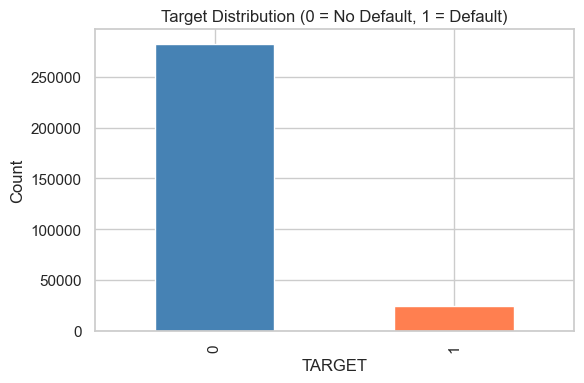

In [5]:
# Target distribution visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
app_train[TARGET_COLUMN].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_title("Target Distribution (0 = No Default, 1 = Default)")
ax.set_xlabel("TARGET")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
# Correlation analysis for numeric variables (without index variable)
numeric_cols = app_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "SK_ID_CURR"]    

target_correlations = (
    app_train[numeric_cols]
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_summary = pd.DataFrame({
    "correlation_with_target": target_correlations,
    "abs_correlation": target_correlations.abs(),
    "missing_percentage": app_train[target_correlations.index].isnull().mean().values * 100,
})

print("Top 10 numeric features most correlated with the target:")
print(corr_summary.head(10).round(4))

Top 10 numeric features most correlated with the target:
                             correlation_with_target  abs_correlation  \
EXT_SOURCE_3                                 -0.1789           0.1789   
EXT_SOURCE_2                                 -0.1605           0.1605   
EXT_SOURCE_1                                 -0.1553           0.1553   
DAYS_BIRTH                                    0.0782           0.0782   
REGION_RATING_CLIENT_W_CITY                   0.0609           0.0609   
REGION_RATING_CLIENT                          0.0589           0.0589   
DAYS_LAST_PHONE_CHANGE                        0.0552           0.0552   
DAYS_ID_PUBLISH                               0.0515           0.0515   
REG_CITY_NOT_WORK_CITY                        0.0510           0.0510   
FLAG_EMP_PHONE                                0.0460           0.0460   

                             missing_percentage  
EXT_SOURCE_3                            19.8253  
EXT_SOURCE_2                           

In [7]:
# Most correlated features explanations from Kaggle dataset description
#EXT_SOURCE_3 - Normalized score from external data source                           
#EXT_SOURCE_2 - Normalized score from external data source                            
#EXT_SOURCE_1 - Normalized score from external data source                             
#DAYS_BIRTH - Client's age in days at the time of application, time only relative to the application                       
#REGION_RATING_CLIENT_W_CITY - Our rating of the region where client lives with taking city into account (1,2,3)           
#REGION_RATING_CLIENT - Our rating of the region where client lives (1,2,3)                   
#DAYS_LAST_PHONE_CHANGE - How many days before application did client change phon                 
#DAYS_ID_PUBLISH  - How many days before the application did client change the identity document with which he applied                       
#REG_CITY_NOT_WORK_CITY - Flag if client's permanent address does not match work address (1=different, 0=same, at city level)               
#FLAG_EMP_PHONE - Did client provide work phone (1=YES, 0=NO)                      

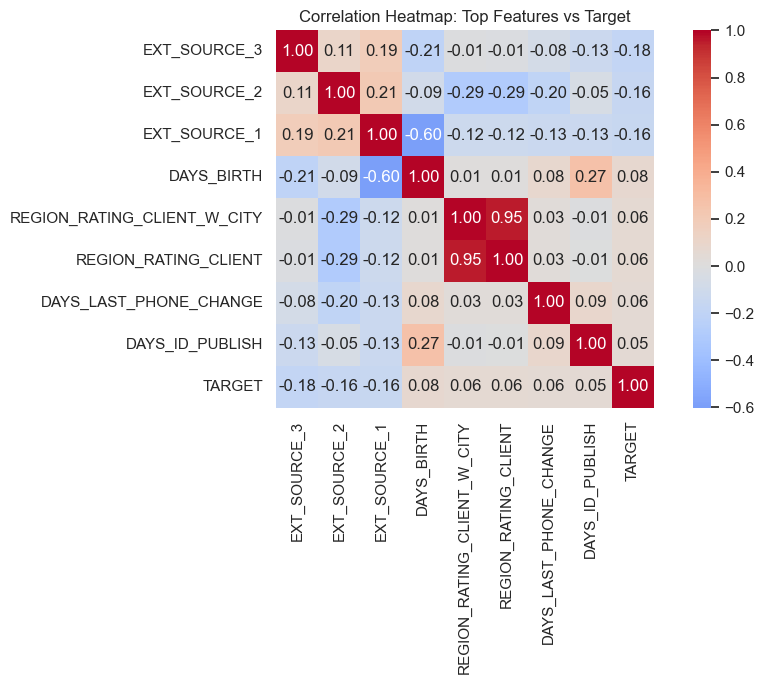

In [8]:
# Heatmap for the strongest numeric relationships
top_corr_features = target_correlations.head(8).index.tolist()
heatmap_features = top_corr_features + [TARGET_COLUMN]

plt.figure(figsize=(10, 7))
sns.heatmap(
    app_train[heatmap_features].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation Heatmap: Top Features vs Target")
plt.tight_layout()
plt.show()

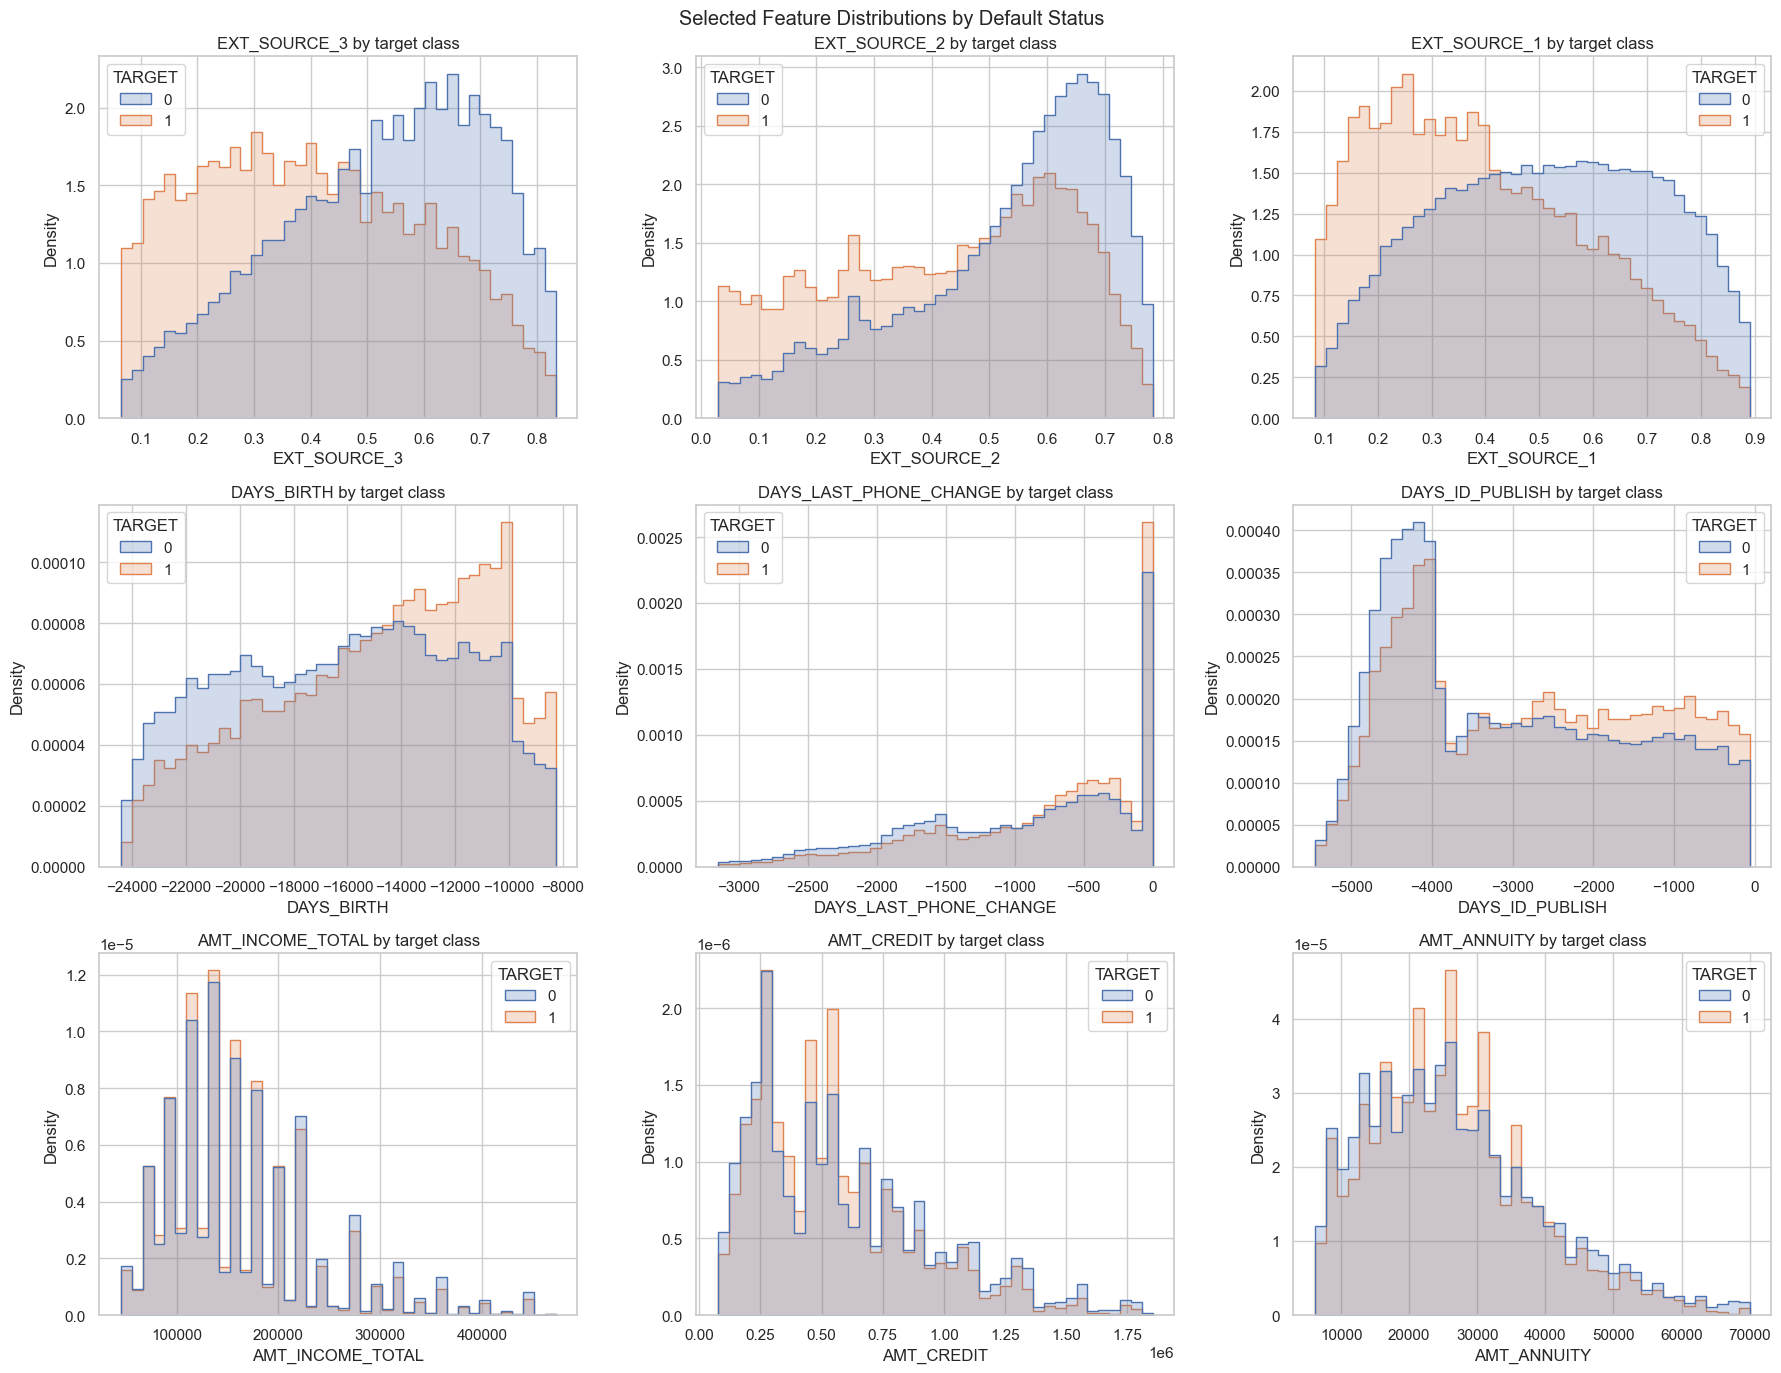

In [9]:
# Distribution plots for selected features by target class
candidate_features = [
    "EXT_SOURCE_3",
    "EXT_SOURCE_2",
    "EXT_SOURCE_1",
    "DAYS_BIRTH",
    "DAYS_LAST_PHONE_CHANGE",
    "DAYS_ID_PUBLISH",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, feature in zip(axes, candidate_features):
    plot_data = app_train[[feature, TARGET_COLUMN]].dropna().copy()

    lower = plot_data[feature].quantile(0.01)
    upper = plot_data[feature].quantile(0.99)
    
    plot_data = plot_data[(plot_data[feature] >= lower) & (plot_data[feature] <= upper)]

    sns.histplot(
        data=plot_data,
        x=feature,
        hue=TARGET_COLUMN,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax
    )
    ax.set_title(f"{feature} by target class")
    ax.set_xlabel(feature)

plt.suptitle("Selected Feature Distributions by Default Status")
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Create new features with **semantic, human-readable names**.

Example naming conventions:
- `income_to_credit_ratio` (not `feat_001`)
- `annuity_to_income_ratio` (not `ratio_2`)
- `bureau_active_credits_count` (not `bur_cnt`)

In [4]:
# Loading supplementary data sources
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
bureau_balance = pd.read_csv(DATA_DIR / "bureau_balance.csv")
previous_app = pd.read_csv(DATA_DIR / "previous_application.csv")
pos_cash = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
installments = pd.read_csv(DATA_DIR / "installments_payments.csv")
credit_card = pd.read_csv(DATA_DIR / "credit_card_balance.csv")

In [11]:
# Quick overview of supplementary tables
table_overview = pd.DataFrame([
    {"table_name": "bureau",
     "rows": bureau.shape[0],
     "columns": bureau.shape[1],
     "join_key": "SK_ID_CURR, SK_ID_BUREAU",
     "granularity": "One row per previous external credit record",
     "description": "Past credits reported by other financial institutions."},
    {"table_name": "bureau_balance",
     "rows": bureau_balance.shape[0],
     "columns": bureau_balance.shape[1],
     "join_key": "SK_ID_BUREAU",
     "granularity": "Monthly history of bureau credits",
     "description": "Status history for credits listed in bureau."},
    {"table_name": "previous_application",
     "rows": previous_app.shape[0],
     "columns": previous_app.shape[1],
     "join_key": "SK_ID_CURR",
     "granularity": "One row per previous Home Credit application",
     "description": "Application data of client's previous loan applications in Home Credit."},
    {"table_name": "POS_CASH_balance",
     "rows": pos_cash.shape[0],
     "columns": pos_cash.shape[1],
     "join_key": "SK_ID_CURR, SK_ID_PREV",
     "granularity": "Monthly balance of POS and cash loans",
     "description": "Monthly snapshots of POS and cash loan accounts."},
    {"table_name": "installments_payments",
     "rows": installments.shape[0],
     "columns": installments.shape[1],
     "join_key": "SK_ID_CURR, SK_ID_PREV",
     "granularity": "One row per installment payment",
     "description": "Repayment history for previously granted loans."},
    {"table_name": "credit_card_balance",
      "rows": credit_card.shape[0],
     "columns": credit_card.shape[1],
     "join_key": "SK_ID_CURR, SK_ID_PREV",
     "granularity": "Monthly credit card balance snapshot",
     "description": "Monthly balance and usage information for credit cards."},
])

display(table_overview)

,table_name,rows,columns,join_key,granularity,description
0,bureau,1716428,17,"SK_ID_CURR, SK_ID_BUREAU",One row per previous external credit record,Past credits reported by other financial insti...
1,bureau_balance,27299925,3,SK_ID_BUREAU,Monthly history of bureau credits,Status history for credits listed in bureau.
2,previous_application,1670214,37,SK_ID_CURR,One row per previous Home Credit application,Application data of client's previous loan app...
3,POS_CASH_balance,10001358,8,"SK_ID_CURR, SK_ID_PREV",Monthly balance of POS and cash loans,Monthly snapshots of POS and cash loan accounts.
4,installments_payments,13605401,8,"SK_ID_CURR, SK_ID_PREV",One row per installment payment,Repayment history for previously granted loans.
5,credit_card_balance,3840312,23,"SK_ID_CURR, SK_ID_PREV",Monthly credit card balance snapshot,Monthly balance and usage information for cred...


In [12]:
app_train["DAYS_EMPLOYED"].max()

365243

In [5]:
## Feature engineering: main table
df = app_train.copy()

def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator

# Some records use 365243 as a placeholder for missing employment duration
df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

# More intuitive time-based variables
df["age_years"] = (-df["DAYS_BIRTH"]) / 365.25
df["employment_years"] = (-df["DAYS_EMPLOYED_CLEAN"]) / 365.25
df["employment_to_age_ratio"] = safe_divide(df["employment_years"], df["age_years"])

# Affordability ratios
df["income_to_credit_ratio"] = safe_divide(df["AMT_INCOME_TOTAL"], df["AMT_CREDIT"])
df["annuity_to_income_ratio"] = safe_divide(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
df["credit_to_goods_ratio"] = safe_divide(df["AMT_CREDIT"], df["AMT_GOODS_PRICE"])
df["credit_to_annuity_ratio"] = safe_divide(df["AMT_CREDIT"], df["AMT_ANNUITY"])

# Household-level scaling
df["income_per_family_member"] = safe_divide(df["AMT_INCOME_TOTAL"], df["CNT_FAM_MEMBERS"])
df["credit_per_family_member"] = safe_divide(df["AMT_CREDIT"], df["CNT_FAM_MEMBERS"])
df["income_per_child"] = safe_divide(df["AMT_INCOME_TOTAL"], df["CNT_CHILDREN"])

# External score aggregation
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

df["external_sources_mean"] = df[ext_cols].mean(axis=1)
df["external_sources_std"] = df[ext_cols].std(axis=1)
df["external_sources_min"] = df[ext_cols].min(axis=1)
df["external_sources_max"] = df[ext_cols].max(axis=1)
df["external_sources_count"] = df[ext_cols].notnull().sum(axis=1)

# Counts of binary flags often used as simple stability / documentation proxies
document_flag_cols = [col for col in df.columns if col.startswith("FLAG_DOCUMENT_")]
contact_flag_cols = ["FLAG_MOBIL", "FLAG_EMP_PHONE", "FLAG_WORK_PHONE", "FLAG_CONT_MOBILE", "FLAG_PHONE", "FLAG_EMAIL"]

df["document_flags_count"] = df[document_flag_cols].sum(axis=1)
df["contact_flags_count"] = df[contact_flag_cols].sum(axis=1)

print(f"Shape after main-table feature engineering: {df.shape}")

Shape after main-table feature engineering: (307511, 140)


In [14]:
bureau_balance["STATUS"].unique()

array(['C', '0', 'X', '1', '2', '3', '5', '4'], dtype=object)

In [7]:
## Feature engineering: bureau_balance + bureau
# bureau_balance contains monthly status history for bureau loans
bb = bureau_balance.copy()

# Mapping monthly status to numeric scale
# X = no loan information for the month, C = closed, 0 = current, 1-5 = increasing delinquency
status_mapping = {
    "X": np.nan,
    "C": 0,
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
}
bb["status_numeric"] = bb["STATUS"].map(status_mapping)
bb["is_closed_month"] = (bb["STATUS"] == "C").astype(int)
bb["is_current_month"] = (bb["STATUS"] == "0").astype(int)
bb["is_delinquent_month"] = bb["STATUS"].isin(["1", "2", "3", "4", "5"]).astype(int)

bureau_balance_agg = bb.groupby("SK_ID_BUREAU").agg(
    bureau_balance_month_count=("MONTHS_BALANCE", "size"),
    bureau_balance_mean_status=("status_numeric", "mean"),
    bureau_balance_max_status=("status_numeric", "max"),
    bureau_balance_bad_status_share=("is_delinquent_month", "mean"),
    bureau_balance_closed_month_share=("is_closed_month", "mean"),
    bureau_balance_current_month_share=("is_current_month", "mean"),
).reset_index()

# Merge monthly bureau history into bureau table
bureau_fe = bureau.copy()
bureau_fe = bureau_fe.merge(bureau_balance_agg, on="SK_ID_BUREAU", how="left")

bureau_fe["is_active_credit"] = (bureau_fe["CREDIT_ACTIVE"] == "Active").astype(int)
bureau_fe["is_closed_credit"] = (bureau_fe["CREDIT_ACTIVE"] == "Closed").astype(int)
bureau_fe["has_credit_overdue"] = (bureau_fe["CREDIT_DAY_OVERDUE"] > 0).astype(int)

bureau_agg = bureau_fe.groupby("SK_ID_CURR").agg(
    bureau_loan_count=("SK_ID_BUREAU", "nunique"),
    bureau_active_loan_count=("is_active_credit", "sum"),
    bureau_closed_loan_count=("is_closed_credit", "sum"),
    bureau_total_credit_sum=("AMT_CREDIT_SUM", "sum"),
    bureau_total_debt_sum=("AMT_CREDIT_SUM_DEBT", "sum"),
    bureau_total_overdue_sum=("AMT_CREDIT_SUM_OVERDUE", "sum"),
    bureau_max_overdue_sum=("AMT_CREDIT_SUM_OVERDUE", "max"),
    bureau_any_overdue=("has_credit_overdue", "max"),
    bureau_mean_days_since_credit=("DAYS_CREDIT", lambda s: (-s).mean()),
    bureau_max_days_since_credit=("DAYS_CREDIT", lambda s: (-s).max()),
    bureau_mean_credit_prolong_count=("CNT_CREDIT_PROLONG", "mean"),
    bureau_balance_mean_status=("bureau_balance_mean_status", "mean"),
    bureau_balance_max_status=("bureau_balance_max_status", "max"),
    bureau_balance_bad_status_share=("bureau_balance_bad_status_share", "mean"),
).reset_index()

bureau_agg["bureau_active_loan_share"] = safe_divide(bureau_agg["bureau_active_loan_count"], bureau_agg["bureau_loan_count"])
bureau_agg["bureau_debt_to_credit_ratio"] = safe_divide(bureau_agg["bureau_total_debt_sum"], bureau_agg["bureau_total_credit_sum"])
bureau_agg["bureau_overdue_to_debt_ratio"] = safe_divide(bureau_agg["bureau_total_overdue_sum"], bureau_agg["bureau_total_debt_sum"])

print(f"bureau_agg shape: {bureau_agg.shape}")
bureau_agg.head()

bureau_agg shape: (305811, 18)


,SK_ID_CURR,bureau_loan_count,bureau_active_loan_count,bureau_closed_loan_count,bureau_total_credit_sum,bureau_total_debt_sum,bureau_total_overdue_sum,bureau_max_overdue_sum,bureau_any_overdue,bureau_mean_days_since_credit,bureau_max_days_since_credit,bureau_mean_credit_prolong_count,bureau_balance_mean_status,bureau_balance_max_status,bureau_balance_bad_status_share,bureau_active_loan_share,bureau_debt_to_credit_ratio,bureau_overdue_to_debt_ratio
0,100001,7,3,4,1453365.000,596686.5,0.0,0.0,0,735.000000,1572,0.0,0.010989,1.0,0.007519,0.428571,0.410555,0.0
1,100002,8,2,6,865055.565,245781.0,0.0,0.0,0,874.000000,1437,0.0,0.299222,1.0,0.255682,0.250000,0.284122,0.0
2,100003,4,1,3,1017400.500,0.0,0.0,0.0,0,1400.750000,2586,0.0,NaN,NaN,NaN,0.250000,0.000000,NaN
3,100004,2,0,2,189037.800,0.0,0.0,0.0,0,867.000000,1326,0.0,NaN,NaN,NaN,0.000000,0.000000,NaN
4,100005,3,2,1,657126.000,568408.5,0.0,0.0,0,190.666667,373,0.0,0.000000,0.0,0.000000,0.666667,0.864992,0.0


In [16]:
previous_app["NAME_CONTRACT_STATUS"].unique()

array(['Approved', 'Refused', 'Canceled', 'Unused offer'], dtype=object)

In [8]:
app_train["NAME_INCOME_TYPE"].unique()

array(['Working', 'State servant', 'Commercial associate', 'Pensioner',
       'Unemployed', 'Student', 'Businessman', 'Maternity leave'],
      dtype=object)

In [9]:
## Feature engineering: previous_application
prev = previous_app.copy()

# Status flags - approved and refuesed
prev["is_approved"] = (prev["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
prev["is_refused"] = (prev["NAME_CONTRACT_STATUS"] == "Refused").astype(int)

# Additional status flags
prev["is_canceled"] = (prev["NAME_CONTRACT_STATUS"] == "Canceled").astype(int)
prev["is_unused_offer"] = (prev["NAME_CONTRACT_STATUS"] == "Unused offer").astype(int)

# Ratio features
prev["application_to_credit_ratio"] = safe_divide(prev["AMT_APPLICATION"], prev["AMT_CREDIT"])
prev["down_payment_to_credit_ratio"] = safe_divide(prev["AMT_DOWN_PAYMENT"], prev["AMT_CREDIT"])

# Additional amount and contract structure features
prev["credit_minus_application"] = prev["AMT_CREDIT"] - prev["AMT_APPLICATION"]
prev["credit_to_goods_ratio"] = safe_divide(prev["AMT_CREDIT"], prev["AMT_GOODS_PRICE"])
prev["annuity_to_credit_ratio"] = safe_divide(prev["AMT_ANNUITY"], prev["AMT_CREDIT"])
prev["goods_to_application_ratio"] = safe_divide(prev["AMT_GOODS_PRICE"], prev["AMT_APPLICATION"])

# Proxy for how expensive the previous credit was in total
prev["total_repayment_to_credit_ratio"] = safe_divide(prev["AMT_ANNUITY"] * prev["CNT_PAYMENT"], prev["AMT_CREDIT"])

# Product-type flags
prev["is_cash_loan"] = (prev["NAME_CONTRACT_TYPE"] == "Cash loans").astype(int)
prev["is_consumer_loan"] = (prev["NAME_CONTRACT_TYPE"] == "Consumer loans").astype(int)
prev["is_revolving_loan"] = (prev["NAME_CONTRACT_TYPE"] == "Revolving loans").astype(int)

# Application-process flags
prev["is_last_application_per_contract"] = (prev["FLAG_LAST_APPL_PER_CONTRACT"] == "Y").astype(int)
prev["is_last_application_in_day"] = prev["NFLAG_LAST_APPL_IN_DAY"].fillna(0).astype(int)
prev["is_insured_on_approval"] = prev["NFLAG_INSURED_ON_APPROVAL"].fillna(0)

# Clean placeholder dates
prev_day_cols = [
    "DAYS_FIRST_DRAWING",
    "DAYS_FIRST_DUE",
    "DAYS_LAST_DUE_1ST_VERSION",
    "DAYS_LAST_DUE",
    "DAYS_TERMINATION",
]

for col in prev_day_cols:
    prev[col] = prev[col].replace(365243, np.nan)

# Contract timeline features
prev["days_to_first_due_after_decision"] = prev["DAYS_FIRST_DUE"] - prev["DAYS_DECISION"]
prev["planned_contract_length_days"] = prev["DAYS_LAST_DUE_1ST_VERSION"] - prev["DAYS_FIRST_DUE"]
prev["actual_contract_length_days"] = prev["DAYS_LAST_DUE"] - prev["DAYS_FIRST_DUE"]
prev["decision_to_termination_days"] = prev["DAYS_TERMINATION"] - prev["DAYS_DECISION"]

# Negative intervals are not meaningful here -> set to missing
interval_cols = [
    "days_to_first_due_after_decision",
    "planned_contract_length_days",
    "actual_contract_length_days",
    "decision_to_termination_days",
]

for col in interval_cols:
    prev.loc[prev[col] < 0, col] = np.nan

# Aggregation per one loan from main table
previous_agg = prev.groupby("SK_ID_CURR").agg(
    previous_application_count=("SK_ID_PREV", "nunique"),
    previous_approved_count=("is_approved", "sum"),
    previous_refused_count=("is_refused", "sum"),
    previous_mean_application_amount=("AMT_APPLICATION", "mean"),
    previous_mean_credit_amount=("AMT_CREDIT", "mean"),
    previous_mean_annuity=("AMT_ANNUITY", "mean"),
    previous_mean_down_payment=("AMT_DOWN_PAYMENT", "mean"),
    previous_mean_application_to_credit_ratio=("application_to_credit_ratio", "mean"),
    previous_mean_down_payment_to_credit_ratio=("down_payment_to_credit_ratio", "mean"),
    previous_mean_payment_count=("CNT_PAYMENT", "mean"),
    previous_mean_days_since_decision=("DAYS_DECISION", lambda s: (-s).mean()),
    previous_canceled_count=("is_canceled", "sum"),
    previous_unused_offer_count=("is_unused_offer", "sum"),
    previous_cash_loan_share=("is_cash_loan", "mean"),
    previous_consumer_loan_share=("is_consumer_loan", "mean"),
    previous_revolving_loan_share=("is_revolving_loan", "mean"),
    previous_mean_goods_price=("AMT_GOODS_PRICE", "mean"),
    previous_mean_down_payment_rate=("RATE_DOWN_PAYMENT", "mean"),
    previous_mean_credit_minus_application=("credit_minus_application", "mean"),
    previous_mean_credit_to_goods_ratio=("credit_to_goods_ratio", "mean"),
    previous_mean_annuity_to_credit_ratio=("annuity_to_credit_ratio", "mean"),
    previous_mean_goods_to_application_ratio=("goods_to_application_ratio", "mean"),
    previous_mean_total_repayment_to_credit_ratio=("total_repayment_to_credit_ratio", "mean"),
    previous_last_application_per_contract_share=("is_last_application_per_contract", "mean"),
    previous_last_application_in_day_share=("is_last_application_in_day", "mean"),
    previous_insured_on_approval_share=("is_insured_on_approval", "mean"),
    previous_mean_days_to_first_due_after_decision=("days_to_first_due_after_decision", "mean"),
    previous_mean_planned_contract_length_days=("planned_contract_length_days", "mean"),
    previous_mean_actual_contract_length_days=("actual_contract_length_days", "mean"),
    previous_mean_decision_to_termination_days=("decision_to_termination_days", "mean"),
).reset_index()

# Shares of approved and refused
previous_agg["previous_approval_rate"] = safe_divide(previous_agg["previous_approved_count"], previous_agg["previous_application_count"])
previous_agg["previous_refusal_rate"] = safe_divide(previous_agg["previous_refused_count"], previous_agg["previous_application_count"])

# Additional rates
previous_agg["previous_canceled_rate"] = safe_divide(previous_agg["previous_canceled_count"], previous_agg["previous_application_count"])
previous_agg["previous_unused_offer_rate"] = safe_divide(previous_agg["previous_unused_offer_count"], previous_agg["previous_application_count"])

# Approved-only aggregates
approved_prev = (
    prev[prev["is_approved"] == 1]
    .groupby("SK_ID_CURR")
    .agg(
        previous_approved_credit_mean=("AMT_CREDIT", "mean"),
        previous_approved_annuity_mean=("AMT_ANNUITY", "mean"),
        previous_approved_application_to_credit_ratio_mean=("application_to_credit_ratio", "mean"),
        previous_approved_payment_count_mean=("CNT_PAYMENT", "mean"),
        previous_approved_down_payment_rate_mean=("RATE_DOWN_PAYMENT", "mean"),
    )
    .reset_index()
)

# Refused-only aggregates
refused_prev = (
    prev[prev["is_refused"] == 1]
    .groupby("SK_ID_CURR")
    .agg(
        previous_refused_application_mean=("AMT_APPLICATION", "mean"),
        previous_refused_goods_price_mean=("AMT_GOODS_PRICE", "mean"),
    )
    .reset_index()
)

previous_agg = previous_agg.merge(approved_prev, on="SK_ID_CURR", how="left")
previous_agg = previous_agg.merge(refused_prev, on="SK_ID_CURR", how="left")

print(f"previous_agg shape: {previous_agg.shape}")
previous_agg.head()

previous_agg shape: (338857, 42)


,SK_ID_CURR,previous_application_count,previous_approved_count,previous_refused_count,previous_mean_application_amount,previous_mean_credit_amount,previous_mean_annuity,previous_mean_down_payment,previous_mean_application_to_credit_ratio,previous_mean_down_payment_to_credit_ratio,...,previous_refusal_rate,previous_canceled_rate,previous_unused_offer_rate,previous_approved_credit_mean,previous_approved_annuity_mean,previous_approved_application_to_credit_ratio_mean,previous_approved_payment_count_mean,previous_approved_down_payment_rate_mean,previous_refused_application_mean,previous_refused_goods_price_mean
0,100001,1,1,0,24835.50,23787.00,3951.000,2520.0,1.044079,0.105940,...,0.0,0.0,0.0,23787.0,3951.000,1.044079,8.0,0.104326,NaN,NaN
1,100002,1,1,0,179055.00,179055.00,9251.775,0.0,1.000000,0.000000,...,0.0,0.0,0.0,179055.0,9251.775,1.000000,24.0,0.000000,NaN,NaN
2,100003,3,3,0,435436.50,484191.00,56553.990,3442.5,0.949329,0.050585,...,0.0,0.0,0.0,484191.0,56553.990,0.949329,10.0,0.050030,NaN,NaN
3,100004,1,1,0,24282.00,20106.00,5357.250,4860.0,1.207699,0.241719,...,0.0,0.0,0.0,20106.0,5357.250,1.207699,4.0,0.212008,NaN,NaN
4,100005,2,1,0,22308.75,20076.75,4813.200,4464.0,1.111173,0.111173,...,0.0,0.5,0.0,40153.5,4813.200,1.111173,12.0,0.108964,NaN,NaN


In [10]:
# Feature engineering: installments_payments
inst = installments.copy()

inst["days_past_due"] = (inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]).clip(lower=0)
inst["days_before_due"] = (inst["DAYS_INSTALMENT"] - inst["DAYS_ENTRY_PAYMENT"]).clip(lower=0)
inst["payment_ratio"] = safe_divide(inst["AMT_PAYMENT"], inst["AMT_INSTALMENT"])

inst["is_late_payment"] = (inst["days_past_due"] > 0).astype(int)
inst["is_underpayment"] = (inst["AMT_PAYMENT"] < inst["AMT_INSTALMENT"]).astype(int)

installments_agg = inst.groupby("SK_ID_CURR").agg(
    installment_record_count=("SK_ID_PREV", "size"),
    installment_loan_count=("SK_ID_PREV", "nunique"),
    installment_mean_payment_ratio=("payment_ratio", "mean"),
    installment_mean_days_past_due=("days_past_due", "mean"),
    installment_max_days_past_due=("days_past_due", "max"),
    installment_mean_days_before_due=("days_before_due", "mean"),
    installment_late_payment_share=("is_late_payment", "mean"),
    installment_underpayment_share=("is_underpayment", "mean"),
    installment_total_installment_amount=("AMT_INSTALMENT", "sum"),
    installment_total_payment_amount=("AMT_PAYMENT", "sum"),
).reset_index()

installments_agg["installment_total_payment_to_instalment_ratio"] = safe_divide(installments_agg["installment_total_payment_amount"], installments_agg["installment_total_installment_amount"])

print(f"installments_agg shape: {installments_agg.shape}")
installments_agg.head()

installments_agg shape: (339587, 12)


,SK_ID_CURR,installment_record_count,installment_loan_count,installment_mean_payment_ratio,installment_mean_days_past_due,installment_max_days_past_due,installment_mean_days_before_due,installment_late_payment_share,installment_underpayment_share,installment_total_installment_amount,installment_total_payment_amount,installment_total_payment_to_instalment_ratio
0,100001,7,2,1.0,1.571429,11.0,8.857143,0.142857,0.0,41195.925,41195.925,1.0
1,100002,19,1,1.0,0.000000,0.0,20.421053,0.000000,0.0,219625.695,219625.695,1.0
2,100003,25,3,1.0,0.000000,0.0,7.160000,0.000000,0.0,1618864.650,1618864.650,1.0
3,100004,3,1,1.0,0.000000,0.0,7.666667,0.000000,0.0,21288.465,21288.465,1.0
4,100005,9,1,1.0,0.111111,1.0,23.666667,0.111111,0.0,56161.845,56161.845,1.0


In [11]:
## Feature engineering: POS_CASH_balance
pos = pos_cash.copy()

pos["is_pos_late"] = (pos["SK_DPD"] > 0).astype(int)
pos["is_pos_late_def"] = (pos["SK_DPD_DEF"] > 0).astype(int)
pos["is_completed_contract"] = (pos["NAME_CONTRACT_STATUS"] == "Completed").astype(int)

pos_agg = pos.groupby("SK_ID_CURR").agg(
    pos_loan_count=("SK_ID_PREV", "nunique"),
    pos_month_count=("MONTHS_BALANCE", "size"),
    pos_mean_dpd=("SK_DPD", "mean"),
    pos_max_dpd=("SK_DPD", "max"),
    pos_mean_dpd_def=("SK_DPD_DEF", "mean"),
    pos_max_dpd_def=("SK_DPD_DEF", "max"),
    pos_late_payment_share=("is_pos_late", "mean"),
    pos_late_payment_def_share=("is_pos_late_def", "mean"),
    pos_completed_contract_share=("is_completed_contract", "mean"),
    pos_mean_future_installments=("CNT_INSTALMENT_FUTURE", "mean"),
).reset_index()

print(f"pos_agg shape: {pos_agg.shape}")
pos_agg.head()

pos_agg shape: (337252, 11)


,SK_ID_CURR,pos_loan_count,pos_month_count,pos_mean_dpd,pos_max_dpd,pos_mean_dpd_def,pos_max_dpd_def,pos_late_payment_share,pos_late_payment_def_share,pos_completed_contract_share,pos_mean_future_installments
0,100001,2,9,0.777778,7,0.777778,7,0.111111,0.111111,0.222222,1.444444
1,100002,1,19,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,15.000000
2,100003,3,28,0.000000,0,0.000000,0,0.000000,0.000000,0.071429,5.785714
3,100004,1,4,0.000000,0,0.000000,0,0.000000,0.000000,0.250000,2.250000
4,100005,1,11,0.000000,0,0.000000,0,0.000000,0.000000,0.090909,7.200000


In [12]:
## Feature engineering: credit_card_balance
cc = credit_card.copy()

cc["balance_to_limit_ratio"] = safe_divide(cc["AMT_BALANCE"], cc["AMT_CREDIT_LIMIT_ACTUAL"])
cc["drawings_to_limit_ratio"] = safe_divide(cc["AMT_DRAWINGS_CURRENT"], cc["AMT_CREDIT_LIMIT_ACTUAL"])
cc["payment_to_minimum_ratio"] = safe_divide(cc["AMT_PAYMENT_TOTAL_CURRENT"], cc["AMT_INST_MIN_REGULARITY"])

cc["is_cc_late"] = (cc["SK_DPD"] > 0).astype(int)

credit_card_agg = cc.groupby("SK_ID_CURR").agg(
    credit_card_count=("SK_ID_PREV", "nunique"),
    credit_card_month_count=("MONTHS_BALANCE", "size"),
    credit_card_mean_balance=("AMT_BALANCE", "mean"),
    credit_card_max_balance=("AMT_BALANCE", "max"),
    credit_card_mean_limit=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    credit_card_mean_utilization=("balance_to_limit_ratio", "mean"),
    credit_card_max_utilization=("balance_to_limit_ratio", "max"),
    credit_card_mean_drawings_to_limit=("drawings_to_limit_ratio", "mean"),
    credit_card_mean_payment_to_minimum=("payment_to_minimum_ratio", "mean"),
    credit_card_mean_dpd=("SK_DPD", "mean"),
    credit_card_max_dpd=("SK_DPD", "max"),
    credit_card_late_payment_share=("is_cc_late", "mean"),
).reset_index()

print(f"credit_card_agg shape: {credit_card_agg.shape}")
credit_card_agg.head()

credit_card_agg shape: (103558, 13)


,SK_ID_CURR,credit_card_count,credit_card_month_count,credit_card_mean_balance,credit_card_max_balance,credit_card_mean_limit,credit_card_mean_utilization,credit_card_max_utilization,credit_card_mean_drawings_to_limit,credit_card_mean_payment_to_minimum,credit_card_mean_dpd,credit_card_max_dpd,credit_card_late_payment_share
0,100006,1,6,0.000000,0.00,270000.000000,0.000000,0.00000,0.000000,NaN,0.000000,0,0.000000
1,100011,1,74,54482.111149,189000.00,164189.189189,0.302678,1.05000,0.013514,1.126212,0.000000,0,0.000000
2,100013,1,96,18159.919219,161420.22,131718.750000,0.115301,1.02489,0.037798,3.777481,0.010417,1,0.010417
3,100021,1,17,0.000000,0.00,675000.000000,0.000000,0.00000,0.000000,NaN,0.000000,0,0.000000
4,100023,1,8,0.000000,0.00,135000.000000,0.000000,0.00000,0.000000,NaN,0.000000,0,0.000000


In [14]:
## Merge all engineered aggregates into the modeling table
df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")
df = df.merge(previous_agg, on="SK_ID_CURR", how="left")
df = df.merge(installments_agg, on="SK_ID_CURR", how="left")
df = df.merge(pos_agg, on="SK_ID_CURR", how="left")
df = df.merge(credit_card_agg, on="SK_ID_CURR", how="left")

new_features = [col for col in df.columns if col not in app_train.columns]

print(f"Final shape after feature engineering: {df.shape}")
print(f"Number of engineered features: {len(new_features)}")

df.head()

Final shape after feature engineering: (307511, 231)
Number of engineered features: 109


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,credit_card_mean_balance,credit_card_max_balance,credit_card_mean_limit,credit_card_mean_utilization,credit_card_max_utilization,credit_card_mean_drawings_to_limit,credit_card_mean_payment_to_minimum,credit_card_mean_dpd,credit_card_max_dpd,credit_card_late_payment_share
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,270000.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
## Preprocessing: missing values imputation
df = df.copy()

# Creating source-availability flags before filling historical aggregates
source_count_columns = {
    "bureau": "bureau_loan_count",
    "previous": "previous_application_count",
    "installments": "installment_record_count",
    "pos": "pos_loan_count",
    "credit_card": "credit_card_count",
}
for source_name, count_col in source_count_columns.items():
    df[f"has_{source_name}_history"] = df[count_col].notna().astype(int)

# Historical aggregates come from supplementary tables merged to SK_ID_CURR.
# Missing values here usually mean "no history in this source", not a random missing entry.
historical_prefixes = ("bureau_", "previous_", "installment_", "pos_", "credit_card_")
historical_cols = [col for col in df.columns if col.startswith(historical_prefixes)]

df[historical_cols] = df[historical_cols].fillna(0)

# Median imputation for remaining numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_to_impute = [col for col in numeric_cols if col not in [TARGET_COLUMN, "SK_ID_CURR"] and col not in historical_cols]
numeric_missing_cols = [col for col in numeric_cols_to_impute if df[col].isna().any()]

# Missing-value indicators only for original numeric columns from app_train
original_numeric_cols = app_train.select_dtypes(include=[np.number]).columns.tolist()
original_numeric_cols = [col for col in original_numeric_cols if col not in [TARGET_COLUMN, "SK_ID_CURR"]]

for col in numeric_missing_cols:
    if col in original_numeric_cols:
        df[f"{col}_was_missing"] = df[col].isna().astype(int)

    median_value = df[col].median()
    if pd.isna(median_value):
        median_value = 0

    df[col] = df[col].fillna(median_value)

In [16]:
## Encoding categoricals
# Missing categories are replaced with an explicit label.
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols:
    df[col] = df[col].fillna("Missing").astype("category")

categorical_feature_names = categorical_cols.copy()

# Converting categories to integer codes
for col in categorical_feature_names:
    df[col] = df[col].cat.codes

# Sanity checks
remaining_missing = df.isna().sum().sum()

print(f"Shape after preprocessing: {df.shape}")
print(f"Remaining missing values in dataset: {remaining_missing}")
print(f"Number of encoded categorical features: {len(categorical_feature_names)}")
print(f"Categorical features: {categorical_feature_names}")

Shape after preprocessing: (307511, 297)
Remaining missing values in dataset: 0
Number of encoded categorical features: 16
Categorical features: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [17]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,DEF_30_CNT_SOCIAL_CIRCLE_was_missing,OBS_60_CNT_SOCIAL_CIRCLE_was_missing,DEF_60_CNT_SOCIAL_CIRCLE_was_missing,DAYS_LAST_PHONE_CHANGE_was_missing,AMT_REQ_CREDIT_BUREAU_HOUR_was_missing,AMT_REQ_CREDIT_BUREAU_DAY_was_missing,AMT_REQ_CREDIT_BUREAU_WEEK_was_missing,AMT_REQ_CREDIT_BUREAU_MON_was_missing,AMT_REQ_CREDIT_BUREAU_QRT_was_missing,AMT_REQ_CREDIT_BUREAU_YEAR_was_missing
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,0,0,0,0,0,0,0,0,0,0
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0,0,0,0,0,0
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,0,0,0,0,0,0,0,0,0,0
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,0,0,0,0,1,1,1,1,1,1
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,0,0,0,0,0,0,0,0,0,0


## 4. Feature Selection

Select **15–20 features** using Boruta or Best Subset Selection.
This reduces dimensionality and improves interpretability of counterfactuals.

In [18]:
# Prepare the dataset for feature selection
modeling_df = df.copy()

model_feature_columns = [col for col in modeling_df.columns if col not in ["SK_ID_CURR", TARGET_COLUMN]]

train_df, test_df = train_test_split(
    modeling_df,
    test_size=TEST_SIZE,
    stratify=modeling_df[TARGET_COLUMN],
    random_state=RANDOM_SEED,
)

train_features_full = train_df[model_feature_columns].copy()
test_features_full = test_df[model_feature_columns].copy()

train_target = train_df[TARGET_COLUMN].copy()
test_target = test_df[TARGET_COLUMN].copy()

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Number of candidate features before selection: {len(model_feature_columns)}")
print(f"Training target mean: {train_target.mean():.4f}")
print(f"Test target mean: {test_target.mean():.4f}")

Training set shape: (246008, 297)
Test set shape: (61503, 297)
Number of candidate features before selection: 295
Training target mean: 0.0807
Test target mean: 0.0807


In [19]:
# Sanity checks before Boruta - Boruta requires only numeric features and no missing values
non_numeric_columns = train_features_full.select_dtypes(exclude=[np.number]).columns.tolist()
remaining_missing_train = train_features_full.isna().sum().sum()
remaining_missing_test = test_features_full.isna().sum().sum()

print(f"Non-numeric columns in training features: {len(non_numeric_columns)}")
print(f"Remaining missing values in training features: {remaining_missing_train}")
print(f"Remaining missing values in test features: {remaining_missing_test}")

Non-numeric columns in training features: 0
Remaining missing values in training features: 0
Remaining missing values in test features: 0


In [64]:
# Smaller sample for Boruta on train set - with full set it was taing too long
BORUTA_SAMPLE_SIZE = 60000
boruta_sample_features, _, boruta_sample_target, _ = train_test_split(
    train_features_full,
    train_target,
    train_size=BORUTA_SAMPLE_SIZE,
    stratify=train_target,
    random_state=RANDOM_SEED,
)
# Downcast types for lower memory usage
boruta_sample_features = boruta_sample_features.copy()

for col in boruta_sample_features.columns:
    if pd.api.types.is_float_dtype(boruta_sample_features[col]):
        boruta_sample_features[col] = boruta_sample_features[col].astype(np.float32)
    elif pd.api.types.is_integer_dtype(boruta_sample_features[col]):
        boruta_sample_features[col] = boruta_sample_features[col].astype(np.int32)

boruta_feature_names = boruta_sample_features.columns.tolist()
boruta_input_matrix = boruta_sample_features.to_numpy(dtype=np.float32, copy=False)
boruta_target_array = boruta_sample_target.to_numpy(dtype=np.int8, copy=False)

print(boruta_input_matrix.shape, boruta_input_matrix.dtype, boruta_target_array.dtype)

(60000, 295) float32 int8


In [65]:
# Boruta config and running on smaller sample
boruta_base_forest = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=30,
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",   
    n_jobs=1,                 
    random_state=RANDOM_SEED,
)
boruta_selector = BorutaPy(
    estimator=boruta_base_forest,
    n_estimators=400,
    perc=100,
    alpha=0.01,
    two_step=True,
    max_iter=50,
    verbose=2,
    random_state=RANDOM_SEED,
)
boruta_selector.fit(boruta_input_matrix, boruta_target_array)

Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	9 / 50
Confirmed: 	0
Tentative: 	295
Rejected: 	0
Iteration: 	10 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	11 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	12 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	13 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	14 / 50
Confirmed: 	99
Tentative: 	47
Rejected: 	149
Iteration: 	15 / 50
Confirmed: 	105
Tentative: 	31
Rejected: 	159
Iteration: 	16 / 50
Confirmed: 	105
Tentative: 	31


,estimator,RandomForestC...0x2875F7AD140)
,n_estimators,400
,perc,100
,alpha,0.01
,two_step,True
,max_iter,50
,random_state,RandomState(M... 0x2875F7AD140
,verbose,2
,early_stopping,False
,n_iter_no_change,20
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400


In [66]:
# Ranking of feature importance by rf_importance (confirmed by Boruta)
ranking_forest = clone(boruta_base_forest)
ranking_forest.set_params(n_estimators=1500)

ranking_forest.fit(train_features_full, train_target)

feature_selection_summary = pd.DataFrame({
    "feature": train_features_full.columns,
    "boruta_rank": boruta_selector.ranking_,
    "boruta_confirmed": boruta_selector.support_,
    "boruta_tentative": boruta_selector.support_weak_,
    "rf_importance": ranking_forest.feature_importances_,
})

feature_selection_summary = feature_selection_summary.sort_values(
    by=["boruta_confirmed", "boruta_tentative", "boruta_rank", "rf_importance", "feature"],
    ascending=[False, False, True, False, True]
).reset_index(drop=True)

display(feature_selection_summary.head(20))

,feature,boruta_rank,boruta_confirmed,boruta_tentative,rf_importance
0,external_sources_mean,1,True,False,0.171371
1,external_sources_min,1,True,False,0.123872
2,external_sources_max,1,True,False,0.120455
3,EXT_SOURCE_3,1,True,False,0.078064
4,EXT_SOURCE_2,1,True,False,0.074344
5,EXT_SOURCE_1,1,True,False,0.029211
6,bureau_mean_days_since_credit,1,True,False,0.028222
7,DAYS_EMPLOYED_CLEAN,1,True,False,0.023525
8,employment_years,1,True,False,0.020100
9,credit_to_goods_ratio,1,True,False,0.017130


In [97]:
# Selecting top confirmed Boruta features with high importance and low correlation
target_feature_count = int(N_FEATURES_TO_SELECT)
correlation_threshold = 0.4

confirmed_features_df = (
    feature_selection_summary[feature_selection_summary["boruta_confirmed"]]
    .sort_values(["rf_importance", "boruta_rank", "feature"], ascending=[False, True, True])
    .reset_index(drop=True)
    .copy()
)

print(f"Number of Boruta-confirmed features: {len(confirmed_features_df)}")
print(f"Max number of final features: {target_feature_count}")
print(f"Fixed absolute correlation threshold: {correlation_threshold}")

Number of Boruta-confirmed features: 109
Max number of final features: 20
Fixed absolute correlation threshold: 0.4


In [98]:
# Correlation matrix for Boruta-confirmed features
confirmed_feature_names = confirmed_features_df["feature"].tolist()
confirmed_feature_matrix = train_features_full[confirmed_feature_names].copy()

# Removin any constant columns
non_constant_confirmed_features = confirmed_feature_matrix.columns[confirmed_feature_matrix.nunique(dropna=False) > 1].tolist()

confirmed_features_df = (
    confirmed_features_df[confirmed_features_df["feature"].isin(non_constant_confirmed_features)]
    .reset_index(drop=True)
    .copy()
)
confirmed_feature_names = confirmed_features_df["feature"].tolist()
confirmed_feature_matrix = confirmed_feature_matrix[confirmed_feature_names]

confirmed_corr_matrix = confirmed_feature_matrix.corr(method="spearman").abs().fillna(0.0)
np.fill_diagonal(confirmed_corr_matrix.values, 0.0)

print(f"Confirmed features after removing constant columns: {len(confirmed_feature_names)}")

Confirmed features after removing constant columns: 109


In [99]:
# Iterative selection: highest rf_importance first, low correlation second
selected_feature_records = []

for _, row in confirmed_features_df.iterrows():
    feature_name = row["feature"]

    if not selected_feature_records:
        selected_feature_records.append({
            "feature": feature_name,
            "rf_importance": row["rf_importance"],
            "boruta_rank": row["boruta_rank"],
            "selection_order": 1,
            "max_abs_corr_with_selected_at_entry": 0.0,
        })
        continue

    already_selected = [item["feature"] for item in selected_feature_records]
    max_corr_to_selected = confirmed_corr_matrix.loc[feature_name, already_selected].max()

    if max_corr_to_selected < correlation_threshold:
        selected_feature_records.append({
            "feature": feature_name,
            "rf_importance": row["rf_importance"],
            "boruta_rank": row["boruta_rank"],
            "selection_order": len(selected_feature_records) + 1,
            "max_abs_corr_with_selected_at_entry": float(max_corr_to_selected),
        })

    if len(selected_feature_records) >= target_feature_count:
        break

selected_feature_names = [item["feature"] for item in selected_feature_records]

print(f"Number of selected features: {len(selected_feature_names)}")

Number of selected features: 20


In [100]:
# Top 20 selected feature table
final_selected_features_df = pd.DataFrame(selected_feature_records).sort_values("selection_order").reset_index(drop=True)

display(final_selected_features_df[["selection_order", "feature", "rf_importance", "boruta_rank", "max_abs_corr_with_selected_at_entry"]])

,selection_order,feature,rf_importance,boruta_rank,max_abs_corr_with_selected_at_entry
0,1,external_sources_mean,0.171371,1,0.000000
1,2,bureau_mean_days_since_credit,0.028222,1,0.247185
2,3,DAYS_EMPLOYED_CLEAN,0.023525,1,0.168700
3,4,credit_to_goods_ratio,0.017130,1,0.061644
4,5,previous_mean_credit_to_goods_ratio,0.015739,1,0.102018
5,6,installment_late_payment_share,0.014522,1,0.155601
6,7,DAYS_BIRTH,0.013826,1,0.295467
7,8,previous_refusal_rate,0.012846,1,0.195681
8,9,bureau_debt_to_credit_ratio,0.011178,1,0.201377
9,10,NAME_EDUCATION_TYPE,0.010319,1,0.152927


In [20]:
selected_feature_names = [
    "external_sources_mean",
    "bureau_mean_days_since_credit",
    "DAYS_EMPLOYED_CLEAN",
    "credit_to_goods_ratio",
    "previous_mean_credit_to_goods_ratio",
    "installment_late_payment_share",
    "DAYS_BIRTH",
    "previous_refusal_rate",
    "bureau_debt_to_credit_ratio",
    "NAME_EDUCATION_TYPE",
    "external_sources_std",
    "credit_card_mean_drawings_to_limit",
    "previous_mean_total_repayment_to_credit_ratio",
    "credit_to_annuity_ratio",
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "DAYS_LAST_PHONE_CHANGE",
    "REGION_RATING_CLIENT_W_CITY",
    "previous_mean_days_since_decision",
    "DAYS_ID_PUBLISH",
]

In [21]:
# Final selected features 
# Replace day-based variables with more interpretable year-based versions
selected_feature_names = selected_feature_names.copy()

selected_feature_names = [
    "employment_years" if col == "DAYS_EMPLOYED_CLEAN" else
    "age_years" if col == "DAYS_BIRTH" else
    col
    for col in selected_feature_names
]
# Removing the last three weakest variables
features_to_remove = [
    "REGION_RATING_CLIENT_W_CITY",
    "previous_mean_days_since_decision",
    "DAYS_ID_PUBLISH",
]
selected_feature_names = [
    col for col in selected_feature_names
    if col not in features_to_remove
]
print(f"Final number of selected features: {len(selected_feature_names)}")

Final number of selected features: 17


In [22]:
# Final train and test matrices based on selected features
X_train = train_features_full[selected_feature_names].copy()
X_test = test_features_full[selected_feature_names].copy()

y_train = train_target.copy()
y_test = test_target.copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train mean: {y_train.mean():.4f}")
print(f"y_test mean: {y_test.mean():.4f}")

X_train shape: (246008, 17)
X_test shape: (61503, 17)
y_train mean: 0.0807
y_test mean: 0.0807


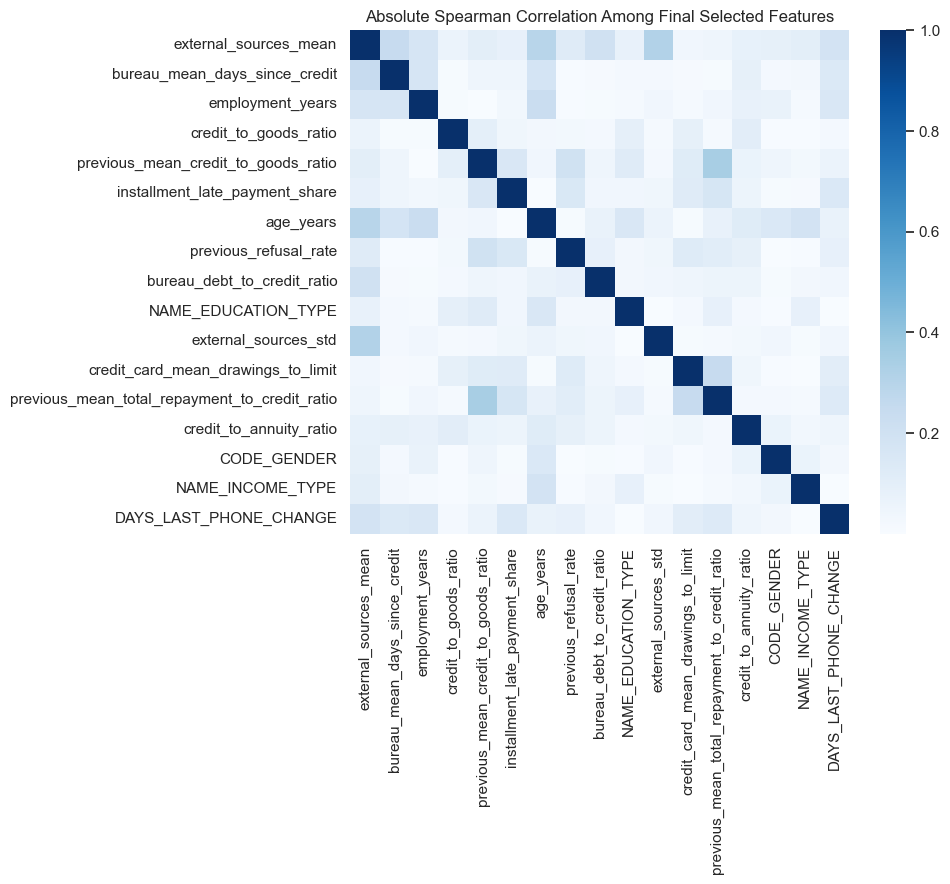

In [23]:
# Correlation matrix among gfinal selected 15 features
selected_corr = X_train.corr(method="spearman").abs()

plt.figure(figsize=(10, 9))
sns.heatmap(selected_corr, cmap="Blues", annot=False)
plt.title("Absolute Spearman Correlation Among Final Selected Features")
plt.tight_layout()
plt.show()

## 5. Model Training

Train a tree-based classifier. LightGBM is recommended, but you may also
try XGBoost or CatBoost.

**Important:** Use `RANDOM_SEED = 42` for all random operations.

In [24]:
# Train classifier
positive_count = (y_train == 1).sum()
negative_count = (y_train == 0).sum()
scale_pos_weight = negative_count / positive_count

model = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=-1,
)
model.fit(X_train, y_train)

y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"Train ROC AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, y_test_proba):.4f}")

scale_pos_weight: 11.39
Train ROC AUC: 0.8212
Test ROC AUC:  0.7708


In [106]:
# Hyperparameter tuning for LightGBM using RandomizedSearchCV
base_lgbm = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    n_jobs=1,
    verbosity=-1,
)
# Search space
param_distributions = {
    "n_estimators": randint(300, 1401),
    "learning_rate": loguniform(0.01, 0.08),
    "num_leaves": randint(16, 128),
    "max_depth": [-1, 3, 4, 5, 6, 8, 10, 12],
    "min_child_samples": randint(20, 201),
    "min_child_weight": loguniform(1e-3, 10),
    "subsample": uniform(0.6, 0.4),          
    "subsample_freq": randint(1, 8),
    "colsample_bytree": uniform(0.6, 0.4),   
    "reg_alpha": loguniform(1e-3, 10),
    "reg_lambda": loguniform(1e-3, 10),
    "min_split_gain": loguniform(1e-4, 0.2),
}
cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=RANDOM_SEED,
)
random_search = RandomizedSearchCV(
    estimator=base_lgbm,
    param_distributions=param_distributions,
    n_iter=60,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)
random_search.fit(X_train, y_train)

model = random_search.best_estimator_

print("Best CV ROC-AUC:", round(random_search.best_score_, 6))
print("\nBest model parameters:")
for param_name, param_value in random_search.best_params_.items():
    print(f"{param_name}: {param_value}")

Fitting 4 folds for each of 60 candidates, totalling 240 fits
Best CV ROC-AUC: 0.767721

Best model parameters:
colsample_bytree: 0.6066351315711425
learning_rate: 0.029004548764296652
max_depth: 4
min_child_samples: 167
min_child_weight: 0.38079493367685613
min_split_gain: 0.0003763473066959232
n_estimators: 1228
num_leaves: 55
reg_alpha: 0.03523233163198313
reg_lambda: 5.583672722754823
subsample: 0.6550083776583973
subsample_freq: 4
Model saved to C:\Users\48784\Documents\Studia\Warsztaty badawcze\Allegro\wut-counterfactual-explanations\models\final_model.pkl
Model verification passed!


In [25]:
model_path = MODELS_DIR / "final_model.pkl"
with open(model_path, "rb") as f:
    model = pickle.load(f)

In [26]:
# Best model AUC scores on train and test
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_test_proba)

print(f"Train ROC AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC AUC:  {auc:.4f}")

Train ROC AUC: 0.8010
Test ROC AUC:  0.7731


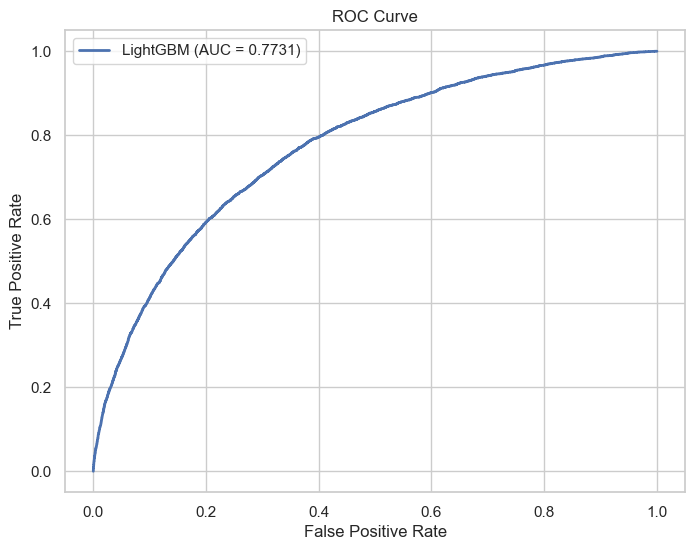

In [29]:
# ROC-AUC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"LightGBM (AUC = {auc:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Masterscale
masterscale = pd.DataFrame({
    "Rating": [
        "AAA", "AA+", "AA", "AA-",
        "A+", "A", "A-",
        "BBB+", "BBB", "BBB-",
        "BB+", "BB", "BB-",
        "B+", "B", "B-",
        "CCC", "CC", "C", "D",
    ],
    "PD_lower": [
        0.0000, 0.0002, 0.0004, 0.0008,
        0.0015, 0.0025, 0.0040,
        0.0060, 0.0100, 0.0150,
        0.0250, 0.0400, 0.0600,
        0.1000, 0.1500, 0.2000,
        0.3000, 0.4000, 0.5000, 0.7000,
    ],
    "PD_upper": [
        0.0002, 0.0004, 0.0008, 0.0015,
        0.0025, 0.0040, 0.0060,
        0.0100, 0.0150, 0.0250,
        0.0400, 0.0600, 0.1000,
        0.1500, 0.2000, 0.3000,
        0.4000, 0.5000, 0.7000, 1.0000,
    ],
})
print(masterscale)

decision_threshold = None

   Rating  PD_lower  PD_upper
0     AAA    0.0000    0.0002
1     AA+    0.0002    0.0004
2      AA    0.0004    0.0008
3     AA-    0.0008    0.0015
4      A+    0.0015    0.0025
5       A    0.0025    0.0040
6      A-    0.0040    0.0060
7    BBB+    0.0060    0.0100
8     BBB    0.0100    0.0150
9    BBB-    0.0150    0.0250
10    BB+    0.0250    0.0400
11     BB    0.0400    0.0600
12    BB-    0.0600    0.1000
13     B+    0.1000    0.1500
14      B    0.1500    0.2000
15     B-    0.2000    0.3000
16    CCC    0.3000    0.4000
17     CC    0.4000    0.5000
18      C    0.5000    0.7000
19      D    0.7000    1.0000


In [32]:
# For each rating boundary, checking what fraction of clients would be classified as bad
threshold_table = masterscale.copy()
threshold_table["decision_threshold"] = threshold_table["PD_upper"]
threshold_table["predicted_bad_share"] = threshold_table["decision_threshold"].apply(
    lambda t: (y_test_proba >= t).mean()
)
threshold_table["predicted_bad_share_pct"] = 100 * threshold_table["predicted_bad_share"]

display(threshold_table[["Rating", "decision_threshold", "predicted_bad_share_pct"]])

,Rating,decision_threshold,predicted_bad_share_pct
0,AAA,0.0002,100.000000
1,AA+,0.0004,100.000000
2,AA,0.0008,100.000000
3,AA-,0.0015,100.000000
4,A+,0.0025,100.000000
5,A,0.0040,100.000000
6,A-,0.0060,100.000000
7,BBB+,0.0100,99.998374
8,BBB,0.0150,99.977237
9,BBB-,0.0250,99.874803


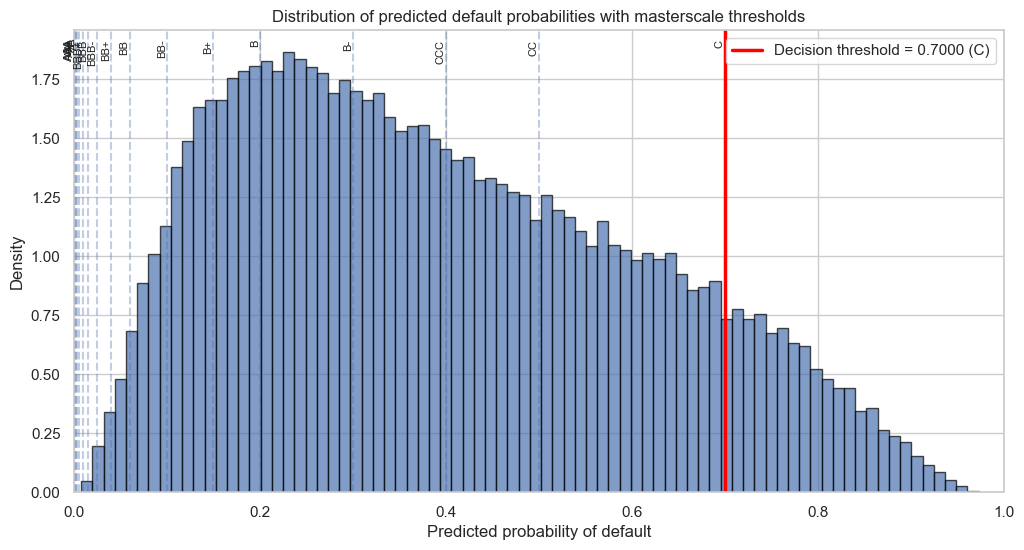

Selected rating cutoff: C
Decision threshold: 0.7000
Share classified as bad: 10.96%


In [33]:
# Choosing the strictest threshold that still classifies at least 10% as bad
valid_thresholds = threshold_table[threshold_table["predicted_bad_share"] >= 0.10].copy()

if valid_thresholds.empty:
    decision_threshold = float(np.quantile(y_test_proba, 0.90))
    selected_rating = "quantile_fallback"
else:
    chosen_row = valid_thresholds.sort_values("decision_threshold", ascending=False).iloc[0]
    decision_threshold = float(chosen_row["decision_threshold"])
    selected_rating = chosen_row["Rating"]

# Visualising probability distribution and rating thresholds
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(y_test_proba, bins=80, density=True, alpha=0.7, edgecolor="black")

x_limit = min(1.0, max(0.25, np.quantile(y_test_proba, 0.995) * 1.15))
ax.set_xlim(0, x_limit)

ymax = ax.get_ylim()[1]

for _, row in masterscale.iloc[:-1].iterrows():
    threshold = row["PD_upper"]
    if threshold <= x_limit:
        ax.axvline(threshold, linestyle="--", alpha=0.35)
        ax.text(
            threshold,
            ymax * 0.98,
            row["Rating"],
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
        )

ax.axvline(
    decision_threshold,
    color="red",
    linewidth=2.5,
    label=f"Decision threshold = {decision_threshold:.4f} ({selected_rating})"
)

ax.set_title("Distribution of predicted default probabilities with masterscale thresholds")
ax.set_xlabel("Predicted probability of default")
ax.set_ylabel("Density")
ax.legend()
plt.show()

print(f"Selected rating cutoff: {selected_rating}")
print(f"Decision threshold: {decision_threshold:.4f}")
print(f"Share classified as bad: {(y_test_proba >= decision_threshold).mean() * 100:.2f}%")

,metric,value
0,ROC AUC,0.773145
1,Accuracy,0.871079
2,Balanced Accuracy,0.647314
3,Precision,0.280184
4,Recall,0.380463
5,F1-score,0.322713
6,Predicted bad share,0.109621


Classification report:

              precision    recall  f1-score   support

           0     0.9438    0.9142    0.9288     56538
           1     0.2802    0.3805    0.3227      4965

    accuracy                         0.8711     61503
   macro avg     0.6120    0.6473    0.6257     61503
weighted avg     0.8903    0.8711    0.8798     61503



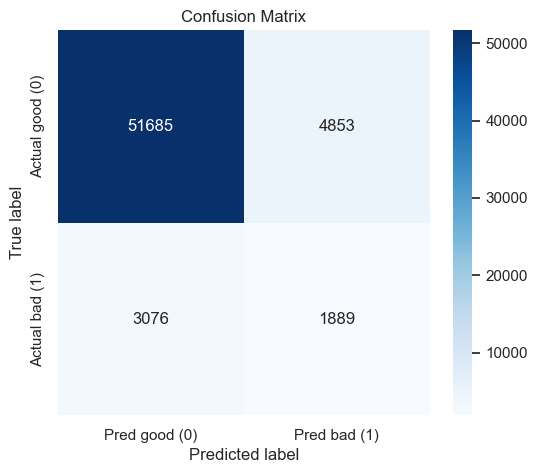

In [41]:
# Cclassification metrics
y_test_pred = (y_test_proba >= decision_threshold).astype(int)

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / cm.sum()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
balanced_accuracy = (recall + specificity) / 2
predicted_bad_share = y_test_pred.mean()

metrics_df = pd.DataFrame({
    "metric": [
        "ROC AUC",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Predicted bad share",
    ],
    "value": [
        roc_auc_score(y_test, y_test_proba),
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1,
        predicted_bad_share,
    ],
})

display(metrics_df)

print("Classification report:\n")
print(classification_report(y_test, y_test_pred, digits=4))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred good (0)", "Pred bad (1)"],
    yticklabels=["Actual good (0)", "Actual bad (1)"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

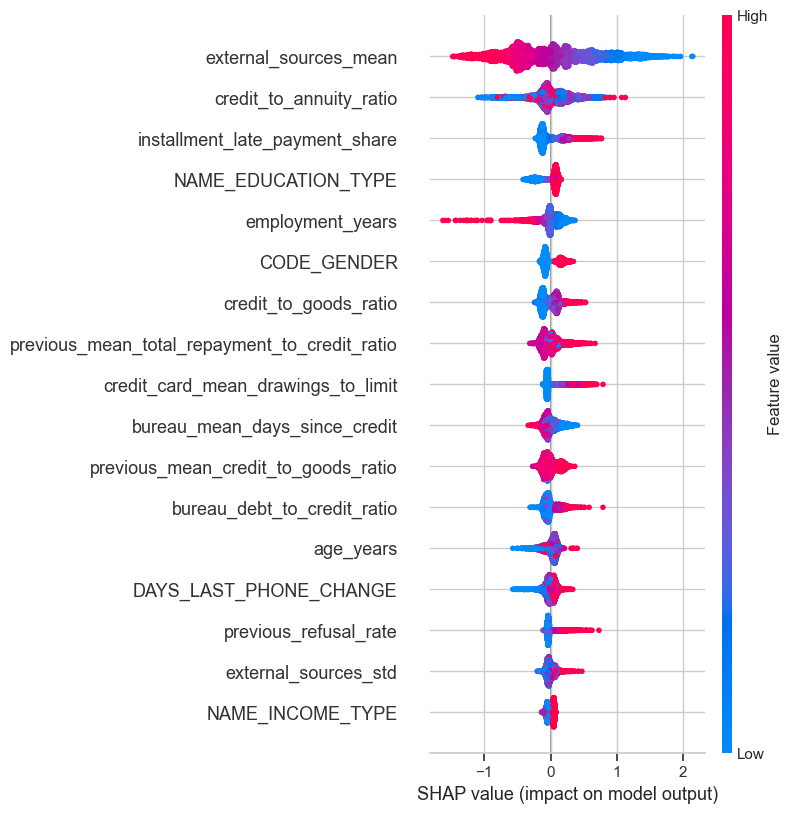

Top 10 features by mean(|SHAP|):


,mean_abs_shap
external_sources_mean,0.537789
credit_to_annuity_ratio,0.205117
installment_late_payment_share,0.152520
NAME_EDUCATION_TYPE,0.118014
employment_years,0.115236
CODE_GENDER,0.112529
credit_to_goods_ratio,0.103784
previous_mean_total_repayment_to_credit_ratio,0.101098
credit_card_mean_drawings_to_limit,0.087434
bureau_mean_days_since_credit,0.086913


In [43]:
# Plotting SHAP summary plot
shap_sample = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=RANDOM_SEED,
)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    shap_values_array = shap_values[1]
elif hasattr(shap_values, "values"):
    shap_values_array = shap_values.values
else:
    shap_values_array = shap_values

shap.summary_plot(shap_values_array, shap_sample, max_display=20)

mean_abs_shap = (
    pd.Series(np.abs(shap_values_array).mean(axis=0), index=shap_sample.columns)
    .sort_values(ascending=False)
)

print("Top 10 features by mean(|SHAP|):")
display(mean_abs_shap.head(20).to_frame("mean_abs_shap"))

Provide a quick discussion how model works "globally"

## 6. Model Serialization

Save the trained model as a `.pkl` file in the `models/` directory.
This file **must be committed** to the repository.

In [31]:
# Save model
model_path = MODELS_DIR / "final_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model saved to {model_path}")

# Verify: reload and check
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)
assert roc_auc_score(y_test, loaded_model.predict_proba(X_test)[:, 1]) == auc
print("Model verification passed!")

Model saved to C:\Users\48784\Documents\Studia\Warsztaty badawcze\Allegro\wut-counterfactual-explanations\models\final_model.pkl
Model verification passed!


## 7. Counterfactual Analysis

### 7a. Select Interesting Test Examples

Choose 10–15 instances from the test set that are interesting for CE analysis:
- Near the decision boundary
- Correctly classified defaults
- Misclassified examples
- High-confidence edge cases

In [ ]:
# TODO: Select interesting examples based on prediction probability

interesting_examples = None

### 7b. DiCE — Diverse Counterfactual Explanations

Generate counterfactuals using the DiCE package.

Documentation: [github.com/interpretml/DiCE](https://github.com/interpretml/DiCE)

In [ ]:
# TODO: Implement DiCE counterfactual generation

### 7c. Alibi Explain — Counterfactual with Prototypes

Generate counterfactuals using the Alibi package.

Documentation: [docs.seldon.io/projects/alibi](https://docs.seldon.io/projects/alibi/en/stable/methods/CFProto.html)

In [ ]:
# TODO: Implement Alibi counterfactual generation

## 8. Evaluation & Benchmarking

In [ ]:
# TODO: Implement DiCE counterfactual generation

## 9. Summary & Next Steps

### What you have done:

---

### AI Tools Used

Document any AI tools used during this project:

| Tool | How it was used |
|------|----------------|
| *e.g., ChatGPT* | *e.g., Helped debug LightGBM hyperparameter tuning* |
| | |